<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#PM2_5" data-toc-modified-id="PM2_5-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>PM2_5</a></span></li><li><span><a href="#Fire" data-toc-modified-id="Fire-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Fire</a></span></li></ul></div>

In [100]:
import rasterio
import rioxarray as rxr
import re
import os
from os import listdir
from os.path import isfile, join
import glob
import datetime
from rasterio.features import rasterize
import geopandas as gpd
import numpy as np
import pandas as pd
import datetime
import warnings
import plotly.figure_factory as ff
from rasterio.transform import from_origin
warnings.filterwarnings('ignore')

In [79]:
directory= '/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_emissions'

In [80]:
# Define bounding box and resolution
xmin, ymin, xmax, ymax = -125, 32, -113, 42.98
res =.03

# Find the number of columns and rows 
cols = int((xmax - xmin) / res)
rows = int((ymax - ymin) / res)
crs = 'EPSG:4326'

transform = rasterio.transform.from_bounds(xmin, ymin, xmax, ymax, cols, rows)

In [81]:
# Create the template raster
meta = {'driver': 'GTiff',
        'dtype': rasterio.float32,
        'nodata': None,#was None
        'width': cols,
        'height': rows,
        'count': 1,
        'crs': crs,
        'transform': transform}

with rasterio.open(directory+'/Emissions_processing/template_raster.tif', 'w', **meta) as dst:
    pass

In [82]:
shp_files = sorted(glob.glob(directory+"/daily_grid_CA/*.shp"),  key=os.path.getmtime)
shapes = []
fire = []
number = []
i = 1

for file in shp_files:
    files = glob.glob('output/*')
    # Read Polygon Shapefile
    vector = gpd.read_file(file)
    vector = vector[vector['dob'] != -9999.0]
    vector = vector.fillna(0)
    # Reprojecting to 4326 coordinate system
    vector = vector.to_crs('EPSG:4326')
    vector['number']= i
    name = file[78:97]
    fire.append(name)
    number.append(i)
    shapes.append(vector)
    i = i + 1
vector = pd.concat(shapes)
vector = gpd.GeoDataFrame(vector)
vector = vector[['dob', 'PM2_5', 'number','geometry']]

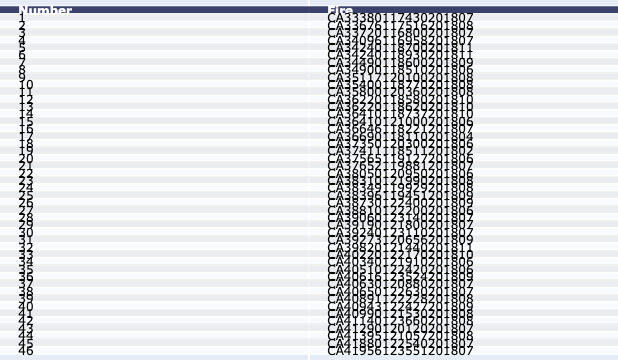

In [83]:
fire_code = {'Number': number,'Fire': fire}
fire_code = pd.DataFrame(fire_code)
fig = ff.create_table(fire_code)
fig.show()

In [84]:
# Get the sum of all PM2.5 emissions in kg
print('Total sum:', sum(vector['PM2_5'].dropna()))
print('Sum on July 30th:', sum(vector['PM2_5'][vector.dob==211]))

Total sum: 371944394.2
Sum on July 30th: 12641989.63


In [85]:
#Convert to points
vector = vector.to_crs('EPSG:5070')
vector.geometry = vector['geometry'].centroid

#Reproject back to EPSG:4326
vector = vector.to_crs('EPSG:4326')
vector.crs = vector.crs

In [86]:
# Get the sum of all PM2.5 emissions in kg
print('Total sum:', vector['PM2_5'].dropna().sum())
print('Sum on July 30th:', vector['PM2_5'][vector['dob']==211].sum())

Total sum: 371944394.20000005
Sum on July 30th: 12641989.629999999


### PM2_5

In [87]:
# Define the desired extent and resolution
xmin, ymin, xmax, ymax = -125, 32, -113, 42.98
resolution = 0.03

# Calculate the width and height based on the extent and resolution
width = int((xmax - xmin) / resolution)
height = int((ymax - ymin) / resolution)

# Create the transformation for the raster
transform = from_origin(xmin + resolution/2, ymax - resolution/2, resolution, resolution)

In [88]:
total = 0
for i in range(1, 366):
    data = vector[vector['dob'] == i]
    output_path = os.path.join(directory+"/Emissions_processing/output/day_"+str(i)+".tif")
    
    raster = rasterio.open(directory+r"/Emissions_processing/template_raster.tif")
    
    #If there are overlapping polygons
    if(len(data.index) == 0):
        meta = raster.meta
        with rasterio.open(output_path, "w", **meta) as dst:
            pass
    else: 
        aggregated_values = np.zeros((height, width), dtype=np.float64)
        for p in data.itertuples():
            #lon, lat = data.x, data.y
            lon, lat = p.geometry.x, p.geometry.y
            col = int((lon - xmin) / resolution)
            row = int((ymax - lat) / resolution)
            if 0 <= row < height and 0 <= col < width:
                aggregated_values[row, col] += p.PM2_5
        aggregated_values = np.nan_to_num(aggregated_values)
        with rasterio.open(output_path, "w", driver="GTiff", width=width,
                   height=height, count=1, dtype=np.float64,
                   crs=vector.crs, transform=transform, fill=0) as dst:
            dst.write(aggregated_values, 1)
        with rasterio.open(output_path) as raster:
            data = raster.read(1)
            sum_value = np.sum(data)
            total = total + sum_value

In [89]:
print("Total Emissions From Shapefiles:", vector['PM2_5'].sum())         
print("Total Emissions From Raster:", total)
print(vector['PM2_5'].sum() - total)

Total Emissions From Shapefiles: 371944394.20000005
Total Emissions From Raster: 371944394.1999999
1.1920928955078125e-07


In [90]:
with rasterio.open(directory + "/Emissions_processing/output/day_211.tif") as raster211:
    data = raster211.read(1)
    sum_value_211 = np.sum(data)

In [91]:
print('Total raster emissions on July 30th:', sum_value_211)

Total raster emissions on July 30th: 12641989.63


### Fire

In [92]:
for i in range(1, 366):
    data = vector[vector['dob'] == i]
    output_path = os.path.join(directory+"/Emissions_processing/output/firenum_day_"+str(i)+".tif")
    
    raster = rasterio.open(directory+"/Emissions_processing/template_raster.tif")
    
    #If there are overlapping polygons
    if len(data.index) == 0:
        meta = raster.meta
        with rasterio.open(output_path, "w", **meta) as dst:
            pass
    else: 
        used = []
        aggregated_values = np.zeros((height, width), dtype=np.float64)
        for p in data.itertuples():
            #lon, lat = data.x, data.y
            lon, lat = p.geometry.x, p.geometry.y
            col = int((lon - xmin) / resolution)
            row = int((ymax - lat) / resolution)
            if 0 <= row < height and 0 <= col < width:
                if(aggregated_values[row, col] == 0):
                    aggregated_values[row, col] = p.number
                if(aggregated_values[row, col] != p.number):
                    temp1 = str(int(aggregated_values[row, col]))
                    temp2 = str(int(p.number))
                    value = temp1 + temp2
                    if(temp1 != temp2 and temp2 not in temp1):
                        value = int(value)
                        aggregated_values[row, col] = value
        aggregated_values = np.nan_to_num(aggregated_values)
        with rasterio.open(output_path, "w", driver="GTiff", width=width,
                   height=height, count=1, dtype=np.float64,
                   crs=vector.crs, transform=transform, fill=0) as dst:
            dst.write(aggregated_values, 1)

In [93]:
dates = []
d = datetime.date(2018,1,1)
while d <= datetime.date(2018,12,31):
    dates.append(datetime.datetime.strftime(d,'%Y/%m/%d'))
    d += datetime.timedelta(days=1)
string1 = ' fire'
string2= ' PM2_5'
pm2_5 =  list(map(lambda orig_string: orig_string + string2, dates))
fire_dates = list(map(lambda orig_string: orig_string + string1, dates))
all_dates = pm2_5 + fire_dates

In [94]:
directory2=directory+'/Emissions_processing/output/'

#tif_files = sorted(glob.glob(directory+"/Emissions_processing/output/*.tif"),  key=os.path.getmtime)
# Get the list of all day of year tif files 
tif_files = [f for f in listdir(directory2) if isfile(join(directory2, f)) & f.endswith(".tif")]
# Sort the files alphabetically and then by the day of year
tif_files=sorted(tif_files)

tif_files.sort(key=lambda var:[int(x) if x.isdigit() else x for x in re.findall(r'[^0-9]|[0-9]+', var)])

#Add directory back to tif_files 
tif_files=[directory2 + s for s in tif_files]

In [106]:
day211=rxr.open_rasterio(directory+'/Emissions_processing/output/day_211.tif')

In [107]:
np.sum(day211)

<xarray.DataArray ()> Size: 8B
array(12641989.63)
Coordinates:
    spatial_ref  int64 8B 0

In [95]:
outpath = directory+"/Emissions_processing/allfires_WBSE.tif"
# Read metadata of first file
with rasterio.open(tif_files[0]) as src1:
    meta = src1.meta
    meta.update(count = len(tif_files))
    with rasterio.open(outpath, 'w', **meta) as dst:
        for id, layer in enumerate(tif_files, start=1):
            with rasterio.open(layer) as src:
                dst.write_band(id, src.read(1))
        #Assign each band a date 
        dst.descriptions = tuple(all_dates)

In [98]:
# Check the raster emissions for July 30th 
with rasterio.open(directory + "/Emissions_processing//allfires_WBSE.tif") as raster_total:
    data = raster_total.read(212)
    sum_value = np.sum(data)
print('Total raster emissions on July 30th:', sum_value)
print(vector['PM2_5'][vector['dob']==212].sum()- sum_value)

Total raster emissions on July 30th: 9106585.0
0.22000000067055225


In [111]:
# Check the total emissions in the raster file
total_sum = 0
with rasterio.open(directory+'/Emissions_processing/allfires_WBSE.tif') as raster:
# Get the number of bands
    num_bands = raster.count 
    print(num_bands)#<- just has the ones with fires 
    # Loop through all bands with emissions data 
    for band_index in range(0,365):
        # Get the band data
        band_data = raster.read(band_index+1)

        # Get the sum of the band data
        band_sum = band_data.sum()
        total_sum = total_sum + band_sum
# Print the sum of the band data
print(total_sum)
print(vector['PM2_5'].sum() - total_sum)

730
371944387.94744873
6.252551317214966
